# Part A - Preprocessing and feature engineering

Research questions

Can we predict self-reported ADHD diagnosis signals among tech workers using workplace environment, demographics, and contextual economic features in a pooled multi-year survey dataset (2014–2023)?<br>

**Objectives of this notebook**
- Harmonise OSMI survey data (different column names, response formats, missingness patterns)
- Engineer clinically meaningful binary signals for ADHD and 12+ comorbid mental-health conditions
- Create clean, model-ready features (demographics, workplace culture, treatment history, geography)
- Handle MNAR patterns and add missingness indicators
- Produce `PartA_df.csv` for downstream modelling

## Section 1. Import Python Packages

ATTENTION please before you run this notebook, please ensure that you have installed required packages. **once** you have them installed, you may comment out the next block of code.

In [1]:
%pip install pandas numpy regex country_converter matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os
import re
from functools import reduce
import country_converter as coco
import matplotlib.pyplot as plt


## Section 2 – Data Ingestion & Header Harmonisation

We walk through every yearly CSV, apply aggressive regex cleaning to column names, drop metadata columns, and concatenate into a single pooled DataFrame.

## Section 3 – Core Preprocessing Functions

- `omsi_headers_clean()` – loads, cleans headers, drops metadata  
- `normalize_text_responses()` – master text normalisation map  
- `MH_collapse_constructs()` – collapses diagnosis columns into binary indicators  
- `coalesce_columns()` – merges equivalent questions asked in different years  
- `process_demographics()`, `process_treatment()`, `process_employer()`, `process_willingness()`, `process_consequences()` – domain-specific mapping to numeric/binary scales  
- `extract_disorder_signals()` – keyword-based parsing of free-text diagnosis fields into 13 binary signals (ADHD + 12 comorbidities)

In [3]:
# HELPER FUNCTION
def omsi_headers_clean(OMSI_file_path):
  """
  This function is intended for the following:
  1.
  This will walk through the directory, read all CSV file, clean column headers.
  drop metadata columns, collect variants of cleaned column names.
  """

  metadata_col = [
      'tags',
      '#',
      'start_date_(utc)',
      'submit_date_(utc)',
      'network_id',
      'response_type',
      'timestamp'
  ]

  all_df = []

  print("=== Starting OSMI survey processing and concatenation ===\n")

  for root, dirs, files in os.walk(OMSI_file_path):
    for file in files:
      if not file.lower().endswith(".csv"):
        continue

      full_path = os.path.join(root, file)
      year = file.split('.')[0]

      try:
        df = pd.read_csv(full_path)
        print(f"→ {file}  shape: {df.shape}")

        #------------------------
        # Step 1: regex cleaning (can add more regex clean for future)
        #------------------------
        rename_map = {}
        for col in df.columns:
          clean = col.lower().strip()
          clean = re.sub(r'</?strong>|</?em>|[\*\?]|[_\?]', '', clean)
          clean = re.sub(r'\s+', '_', clean)
          clean = re.sub(r'^\d+\.?\s*', '', clean)
          clean = re.sub(r'[:?-]+$', '', clean)
          clean = re.sub(r'-', '_', clean)
          rename_map[col] = clean

        df.rename(columns=rename_map, inplace=True)

        # Step 2: Detect duplicates after cleaning and make unique
        drop_cols = [
            col for col in df.columns
            if any(kw in col for kw in metadata_col)
        ]

        if drop_cols:
          df.drop(columns=drop_cols, inplace=True, errors='ignore')
          print(f"   Dropped {len(drop_cols)} metadata columns: {drop_cols}")


        # Handle duplicate column names after cleaning
        if not df.columns.is_unique:
          counts = {}
          new_cols = []
          for col in df.columns:
            if col in counts:
              counts[col] += 1
              new_cols.append(f"{col}_dup{counts[col]}")
            else:
              counts[col] = 0
              new_cols.append(col)
          df.columns = new_cols
          print(f"   Renamed duplicate columns in {file}")
        
        df['year'] = year
        
        all_df.append(df)
        print(f"   After processing: {df.shape}\n")

      except Exception as e:
        print(f"Error {file}: {e}\n")

  if not all_df:
    raise ValueError("No CSV files were successfully processed.")

  # ────────────────────────────────────────────────
  # Step 4: Concatenate
  # ────────────────────────────────────────────────
  print("Concatenating all years...")
  merged_df = pd.concat(all_df, ignore_index=True, sort=False)

  # Make sure 'year' is first column
  cols = ['year'] + [c for c in merged_df.columns if c != 'year']
  merged_df = merged_df[cols]

  # Final report
  print(f"\nFinal pooled shape: {merged_df.shape}")
  print(f"Years: {sorted(merged_df['year'].unique())}")
  print(f"Total unique columns (incl. year): {len(merged_df.columns)}")

  return merged_df

def normalize_text_responses(
    df: pd.DataFrame,
    normalize_map: dict,
    exclude_cols: list | None = None,
    log_unknown: bool = True,
    log_prefix: str = "[normalize] Unknown value in"
) -> pd.DataFrame:

    """
    Function purpose:
    1. Look for columns that dtypes in string or object
    2. convert them all to string for processing
    3. normalize the responses according to MASTER_TEXT_NORMALIZE
    4. print out text that hasn't been normalize from each processed columns 
    (user to review if any more text need to be add to MASTER_TEXT_NORMALIZE)
    5. replcae the normalize responses to the corresponding columns.
    """

    df = df.copy()

    if exclude_cols is None:
        exclude_cols = []

    text_cols = [
        col for col in df.columns
        if (
            pd.api.types.is_object_dtype(df[col])
            or pd.api.types.is_string_dtype(df[col])
        )
        and col not in exclude_cols
    ]
    print(text_cols)

    for col in text_cols:

        # ---- SAFE STRING CAST FIRST ----
        s = df[col].astype("string")

        # ---- SKIP NUMERIC-LIKE COLUMNS ----
        if (
            s.str.replace(r'[\d\.\-]', '', regex=True)
            .str.strip()
            .eq('')
            .all(skipna=True)
        ):
            continue

        # ---- NORMALISE TEXT ----
        s = (
            s.str.strip()
             .str.lower()
        )

        # ---- LOG UNKNOWN VALUES ----
        if log_unknown:

            known_keys = set(normalize_map.keys())

            unknown_mask = (
                s.notna()
                & ~s.isin(known_keys)
            )

            if unknown_mask.any():

                unknowns = (
                    s[unknown_mask]
                    .value_counts()
                    .head(12)
                )

                print(f"{log_prefix} '{col}':")

                if len(unknowns) > 0:
                    print(unknowns.to_string())
                else:
                    print("(no new unknown values)")

                print()

        # ---- APPLY NORMALISATION ----
        df[col] = s.replace(normalize_map)

    return df

def MH_collapse_constructs(df, construct_map, drop_source_cols=True):
  """
  Collapses multiple survey item variants into binary construct indicators.
  this is targeted for MH status map
  Rule:
  - If ANY source column contains a non-null, non-empty string → 1
  - Else → 0
  """

  df = df.copy()

  for new_col, source_cols in construct_map.items():
    # Only use columns that actually exist
    existing = [c for c in source_cols if c in df.columns]

    if not existing:
      print(f"No columns found for MH_status '{new_col}'")
      continue

    # Boolean mask: any non-null AND non-empty string on any column
    mask = (
        df[existing].notna() &
        df[existing].astype(str).apply(lambda s: s.str.strip().ne(''))
    )
    df[new_col] = mask.any(axis=1).astype(int)

    if drop_source_cols:
        df.drop(columns=existing, inplace=drop_source_cols)

  return df

def coalesce_columns(df, cols):
    """
    This function is used to target survery questions that are similar in context but in different years
    Yr, A, B, C --> D
    14, 1, 0, 0 --> 1
    15, 0, 1, 0 --> 1
    16, 0, 0, 1 --> 1
    They won't crash into each other
    """
    valid_cols = [c for c in cols if c in df.columns]

    if not valid_cols:
        return pd.Series(np.nan, index=df.index)

    return reduce(
        lambda a, b: a.combine_first(b),
        [df[c] for c in valid_cols]
    )

def process_demographics(
    df,
    column_map,
    drop_source=False,
    inplace=False
):
    """
    Extract and normalize demographic features from raw survey columns.
    """
    if inplace:
        df_out = df
    else:
        df_out = df.copy()

    binary_cols = ['self_employed', 'tech_current', 'remote_work', 'prev_employer', 'tech_role','tech_previous']

    for target_col, source_cols in column_map.items():
        series = coalesce_columns(df_out, source_cols)

        if series is None or series.isna().all():
            df_out[target_col] = pd.NA
            continue

        if target_col in binary_cols:
            cleaned = (
                series
                .astype(str)
                .str.lower()
                .str.strip()
                .replace({'nan': pd.NA, 'NaN': pd.NA})  # safer handling
            )
            df_out[target_col] = cleaned.map(BINARY_STRICT).astype('Int64')

        elif target_col in {'company_size'}:
            cleaned = (
                series
                .astype(str)
                .str.lower()
                .str.strip()
                .replace({'nan': pd.NA, 'NaN': pd.NA})  # safer handling
            )
            df_out[target_col] = cleaned.map(SIZE_MAP).astype('Int64')

        else:
            df_out[target_col] = series

    # --- Optional: Drop source columns ---
    if drop_source:
        dropped = set()
        for source_list in column_map.values():
            existing = [c for c in source_list if c in df_out.columns]
            if existing:
                df_out.drop(columns=existing, inplace=True, errors='ignore')
                dropped.update(existing)
        if dropped:
            print(f"Dropped {len(dropped)} source columns: {', '.join(sorted(dropped))}")

    return df_out if not inplace else None

def process_treatment(
    df,
    column_map,
    drop_source=False,
    inplace=False
    ):
  """
  Process mental-health treatment-related survey questions across years.
  """
  if inplace:
     df_out = df
  else:
     df_out = df.copy()

  #BIN_PERCEP_COLS = ['mh_knowledge_on_resource', 'productivity_impacted_flag']
  for target_col in column_map:
     series = coalesce_columns(df_out, column_map[target_col])
     # this will merge all the columns that need mergeing
      

  # Decide how to process this column
     if target_col in {'mh_coverage_access'}:
         df_out[target_col] = pd.to_numeric(series, errors='coerce').astype('Int64')
         
     elif target_col in {'mh_treatment_history'}:
        cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA})
        df_out[target_col] = cleaned.map(BINARY_STRICT).astype('Int64')

     elif target_col in {'mh_knowledge_on_resource', 'productivity_impacted_flag'}:
        cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA})
        df_out[target_col] = cleaned.map(BINARY_PERCEPTION).astype('Int64')

     elif target_col == 'productivity_affected_pct':
         df_out[target_col] = pd.Categorical(series, categories=PCT_ORDER, ordered=True)

     elif target_col in {'work_impairment_treated', 'work_impairment_untreated'}:
         cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA})
         df_out[target_col] = cleaned.map(FREQUENCY_MAP).astype('Int64')

     else:
    # fallback: keep as-is (or raise warning)
        df_out[target_col] = series
        print(f"Warning: no specific processor defined for '{target_col}'")

     
# --- Optional: Drop source columns ---
     if drop_source:
        dropped = set()
        for source_list in column_map.values():
            existing = [c for c in source_list if c in df_out.columns]
            if existing:
                df_out.drop(columns=existing, inplace=True, errors='ignore')
                dropped.update(existing)
        if dropped:
            print(f"Dropped {len(dropped)} source columns: {', '.join(sorted(dropped))}")

     return df_out if not inplace else None

def process_employer(
      df,
      column_map,
      drop_source=False,
      inplace=False
):
   """
   Process employer mapping survey question across years
   """
   if inplace:
      df_out = df
   else:
      df_out = df.copy()
   for target_col in column_map:
      series = coalesce_columns(df_out, column_map[target_col])

      if target_col in {'work_mh_importance_score', 'work_ph_importance_score'}: #ok
         df_out[target_col] = pd.to_numeric(series, errors='coerce').astype('Int64')
         
      elif target_col in {
         'work_mh_benefits_current',
         'work_mh_resources_current',
         'employer_discussed_mh_wellness',
         'work_mh_vs_physical_equal',
         'work_mh_comm_current',
         'knowing_health_care_coverage'
         }:
        cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA}) #ok
        df_out[target_col] = cleaned.map(BINARY_STRICT).astype('Int64')

      elif target_col in {
         'work_mh_benefits_previous', 
         'work_mh_resources_previous',
         'aware_of_mh_care_options_previous',
         'work_mh_comm_previous',
         'supportive_response_observed_or_experienced'
         }:
        
        cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA}) #
        df_out[target_col] = cleaned.map(BINARY_PERCEPTION).astype('Int64')

      elif target_col in {'how_easy_medical_leave_mh'}:
         cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA})
         df_out[target_col] = cleaned.map(DIFFICULTY_MAP).astype('Int64')

      else:
    # fallback: keep as-is (or raise warning)
        df_out[target_col] = series
        print(f"Warning: no specific processor defined for '{target_col}'")

# --- Optional: Drop source columns ---
      if drop_source:
        dropped = set()
        for source_list in column_map.values():
            existing = [c for c in source_list if c in df_out.columns]
            if existing:
                df_out.drop(columns=existing, inplace=True, errors='ignore')
                dropped.update(existing)
        if dropped:
            print(f"Dropped {len(dropped)} source columns: {', '.join(sorted(dropped))}")

      return df_out if not inplace else None

def process_willingness(
    df,
    column_map,
    drop_source=False,
    inplace=False
):
    """
    Process willingness / openness / disclosure related survey questions across years
    """
    if inplace:
        df_out = df
    else:
        df_out = df.copy()

    for target_col in column_map:
        series = coalesce_columns(df_out, column_map[target_col])

        if series is None or series.isna().all():
            df_out[target_col] = pd.NA
            continue

        if target_col in {
            'industry_support_mh',
        }:
            df_out[target_col] = pd.to_numeric(series, errors='coerce').astype('Int64')

        elif target_col in {
            'mh_share_interview', 
            'ph_share_interview',
            'open_to_discuss_coworkers',
            'open_to_discuss_supervisor_current',
            'open_to_discuss_supervisor_prev',
            'discuss_mh_with_prev_coworkers',
            'vicarious_stigma_effect',
            
        }:
            cleaned = (
                series
                .astype(str)
                .str.lower()
                .str.strip()
                .replace({'nan': pd.NA, 'NaN': pd.NA})
            )
            df_out[target_col] = cleaned.map(BINARY_PERCEPTION).astype('Int64')
        
        elif target_col in {
           'discussed_with_coworkers',
           'discussed_with_employer',
           'disclose_mh_clients_business_current',
           'disclose_mh_coworkers_current',
           'past_disclose_mh_coworker',
           'observed_coworker_discuss_mh',
           'willing_interview_followup',
           'prev_coworker_discussed_mh_with_you',
           'openly_identified_mh_at_work',
           'discuss_mh_with_prev_employer'

        }:
           cleaned = (
                series
                .astype(str)
                .str.lower()
                .str.strip()
                .replace({'nan': pd.NA, 'NaN': pd.NA})
           )
           df_out[target_col] = cleaned.map(BINARY_STRICT).astype('Int64')


        elif target_col in {'willing_share_family'}:
            cleaned = (
                series
                .astype(str)
                .str.lower()
                .str.strip()
                .replace({'nan': pd.NA, 'NaN': pd.NA})
            )
            df_out[target_col] = cleaned.map(
               lambda x: WILLINGNESS_MAP.get(x, x if pd.isna(x) or str(x).isdigit() or (str(x).lstrip('-').isdigit()) else pd.NA)
            )
            df_out[target_col] = pd.to_numeric(df_out[target_col], errors='coerce').astype('Int64')

        elif target_col in {'mental_vs_physical_comfort_prev_employer','mental_vs_physical_comfort_coworker'}:
            cleaned = (
                series
                .astype(str)
                .str.lower()
                .str.strip()
                .replace({'nan': pd.NA, 'NaN': pd.NA})
            )
            df_out[target_col] = cleaned.map(PHYSICAL_MENTAL_MAP).astype('Int64')


        else:
            df_out[target_col] = series
            print(f"Warning: no specific processor defined for '{target_col}'")

    # --- Drop source columns (only after all targets are processed) ---
    if drop_source:
        dropped = set()
        for source_list in column_map.values():
            existing = [c for c in source_list if c in df_out.columns]
            if existing:
                df_out.drop(columns=existing, inplace=True, errors='ignore')
                dropped.update(existing)
        if dropped:
            print(f"Dropped {len(dropped)} source columns: {', '.join(sorted(dropped))}")

    return df_out if not inplace else None

def process_consequences(
      df,
      column_map,
      drop_source=False,
      inplace=False
):
   """
   Process employer mapping survey question across years
   """
   if inplace:
      df_out = df
   else:
      df_out = df.copy()
   for target_col in column_map:
      series = coalesce_columns(df_out, column_map[target_col])

      if target_col in {
         'prev_employer_mh_importance', 
         'prev_employer_ph_importance',
         'opinion_of_coworker_reaction_on_MH'
         }:
         df_out[target_col] = pd.to_numeric(series, errors='coerce').astype('Int64')
         
      elif target_col in {
         'negative_consequences_observed',
         'career_hurt_identified',
         }:
        cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA})
        df_out[target_col] = cleaned.map(BINARY_STRICT).astype('Int64')

      elif target_col in {
         'discuss_employer_neg_conseq', 
         'prev_employer_neg_conseq_discuss',
         'mh_vs_physical_importance_prev',
         'anonymity_protected_current',
         'anonymity_protected_prev',
         "neg_conseq_discuss_physical_current",
         "neg_conseq_discuss_physical_previous",
         "observed_neg_conseq_coworkers_mh",
         "neg_conseq_discuss_physical_current",
         "coworkers_neg_view_if_mh_known",
         "relationship_affect_client",
         "relationship_affect_cowoker"
         }:
        cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA}) #
        df_out[target_col] = cleaned.map(BINARY_PERCEPTION).astype('Int64')

      elif target_col in {'work_impact'}:
         cleaned = series.astype(str).str.lower().str.strip().replace({'NaN': pd.NA})
         df_out[target_col] = cleaned.map(FREQUENCY_MAP).astype('Int64')

      else:
    # fallback: keep as-is (or raise warning)
        df_out[target_col] = series
        print(f"Warning: no specific processor defined for '{target_col}'")

# --- Optional: Drop source columns ---
      if drop_source:
        dropped = set()
        for source_list in column_map.values():
            existing = [c for c in source_list if c in df_out.columns]
            if existing:
                df_out.drop(columns=existing, inplace=True, errors='ignore')
                dropped.update(existing)
        if dropped:
            print(f"Dropped {len(dropped)} source columns: {', '.join(sorted(dropped))}")

      return df_out if not inplace else None

def split_conditions(text):
    """
    Split diagnosis text only on '|' (the real separator in your data).
    Preserves commas inside parentheses.
    """
    if pd.isna(text):
        return []
    text = str(text).lower().strip()
    # Only split on the pipe character used in your data
    parts = [p.strip() for p in text.split("|") if p.strip()]
    return parts

def match_disorder_text(text, keyword_map, signal_cols):
    """
    Match cleaned text parts against keyword map.
    Returns Series with 0/1 for each signal column + 'other_disorder'
    """
    signals = {k: 0 for k in signal_cols}
    other_flag = 0

    parts = split_conditions(text)

    for entry in parts:
        matched = False
        clean_entry = entry.replace("(", "").replace(")", "").strip()

        for signal, keywords in keyword_map.items():
            if signal not in signal_cols:
                continue
            # Substring match (case already lowered)
            if any(k in clean_entry for k in keywords):
                signals[signal] = 1
                matched = True

        if not matched and clean_entry:
            other_flag = 1

    signals["other_disorder"] = other_flag

    return pd.Series(signals)

def extract_disorder_signals(row, clinical_cols, keyword_map, signal_cols):
    """
    Combine text from multiple columns for one row and match disorders.
    """
    texts = []
    for c in clinical_cols:
        if c in row and pd.notna(row[c]):
            texts.extend(split_conditions(row[c]))

    # Join for logging/debug if needed
    combined = " | ".join(texts)

    return match_disorder_text(combined, keyword_map, signal_cols)

def process_mh_extra(
    df,
    column_map,
    disorder_signal_cols,
    keyword_map,
    drop_source=False,
    inplace=False,
    clinical_cols_key='clinical_diagnosed',
    self_cols_key='self_diagnosed',
    other_cols_key='other_disorder'
):
    """
    Integrate mental health extra fields:
    - Coalesce simple yes/no fields and map to numeric using BINARY_PERCEPTION
    - Parse free-text diagnosis fields into binary disorder signals
    - Optionally drop original source columns
    """
    if inplace:
        df_out = df
    else:
        df_out = df.copy()

    # ── 1. Coalesce and map simple yes/no/maybe fields ──────────────────────────
    simple_fields = ['current_mh', 'past_mh', 'diagnosed_mh', 'family_history_mh']

    for new_col in simple_fields:
        if new_col not in column_map:
            continue

        # Coalesce
        series = coalesce_columns(df_out, column_map[new_col])
        if series is None or series.isna().all():
            df_out[new_col] = pd.NA
            continue

        # Normalize and map using BINARY_PERCEPTION
        cleaned = (
            series
            .astype(str)
            .str.lower()
            .str.strip()
            .replace({'nan': pd.NA, 'NaN': pd.NA})
        )

        if new_col == 'diagnosed_mh':
           df_out[new_col] = cleaned.map(BINARY_STRICT).astype('Int64')
        else:
            df_out[new_col] = cleaned.map(BINARY_PERCEPTION).astype('Int64')

    # ── 2. Create clinical signal from 'diagnosed_mh' (optional fallback) ──────
    df_out['signal_from_clinical'] = 0
    if 'diagnosed_mh' in df_out.columns:
        # If BINARY_PERCEPTION already mapped "yes"→2, "maybe"→1, etc.
        # We can use >0 as positive signal (or customize)
        df_out['signal_from_clinical'] = (
           (df_out['diagnosed_mh'] > 0)
           .fillna(False)
           .astype(int)
           )

    # ── 3. Get free-text column lists ──────────────────────────────────────────
    clinical_cols = [c for c in column_map.get(clinical_cols_key, []) if c in df_out.columns]
    self_cols     = [c for c in column_map.get(self_cols_key, [])     if c in df_out.columns]
    other_cols    = [c for c in column_map.get(other_cols_key, [])    if c in df_out.columns]

    print("Clinical free-text cols:", clinical_cols)
    print("Self-suspected free-text cols:", self_cols)
    print("Other free-text cols:", other_cols)

    # Initialize disorder signal columns to 0 if not exist
    for col in disorder_signal_cols:
        if col not in df_out.columns:
            df_out[col] = 0

    df_out['signal_from_self'] = 0
    df_out['other_disorder']   = 0

    # ── 4. Row-wise free-text parsing & signal extraction ──────────────────────
    for idx, row in df_out.iterrows():
        # Clinical diagnosed text
        for col in clinical_cols:
            if pd.notna(row[col]):
                signals = extract_disorder_signals(
                    row, [col], keyword_map, disorder_signal_cols
                )
                for s in disorder_signal_cols:
                    if signals[s] == 1:
                        df_out.at[idx, s] = 1
                if signals.sum() > 0:
                    df_out.at[idx, 'signal_from_clinical'] = 1

        # Self-suspected text
        for col in self_cols:
            if pd.notna(row[col]):
                signals = extract_disorder_signals(
                    row, [col], keyword_map, disorder_signal_cols
                )
                for s in disorder_signal_cols:
                    if signals[s] == 1:
                        df_out.at[idx, s] = 1
                if signals.sum() > 0:
                    df_out.at[idx, 'signal_from_self'] = 1

        # Other free-text columns
        for col in other_cols:
            if pd.notna(row[col]):
                signals = extract_disorder_signals(
                    row, [col], keyword_map, disorder_signal_cols
                )
                for s in disorder_signal_cols:
                    if signals[s] == 1:
                        df_out.at[idx, s] = 1

    # ── 5. Optional: drop original source columns ──────────────────────────────
    if drop_source:
        dropped = set()
        for source_list in column_map.values():
            existing = [c for c in source_list if c in df_out.columns]
            if existing:
                df_out.drop(columns=existing, inplace=True, errors='ignore')
                dropped.update(existing)
        if dropped:
            print(f"Dropped {len(dropped)} source columns: {', '.join(sorted(dropped))}")

    return df_out if not inplace else None


Column header that matched with the assistant of fuzzywuzzy

In [4]:
#================================================================================================
# Column header rename, grouping, mapping over 170 columns

MH_status_map = {
    'adhd': [
        'attention_deficit_hyperactivity_disorder',
        'attention_deficit_hyperactivity_disorder.1',
        'attention_deficit_hyperactivity_disorder.2'
      ],
    'anxiety': [
        'anxiety_disorder_(generalized,_social,_phobia,_etc)',
        'anxiety_disorder_(generalized,_social,_phobia,_etc).1',
        'anxiety_disorder_(generalized,_social,_phobia,_etc).2'
      ],
    'mood': [
        'mood_disorder_(depression,_bipolar_disorder,_etc)',
        'mood_disorder_(depression,_bipolar_disorder,_etc).1',
        'mood_disorder_(depression,_bipolar_disorder,_etc).2'
      ],
    'eating': [
        'eating_disorder_(anorexia,_bulimia,_etc)',
        'eating_disorder_(anorexia,_bulimia,_etc).1',
        'eating_disorder_(anorexia,_bulimia,_etc).2'
      ],
    'ocd': [
        'obsessive_compulsive_disorder',
        'obsessive_compulsive_disorder.1',
        'obsessive_compulsive_disorder.2'
      ],
    'ptsd': [
        'post_traumatic_stress_disorder',
        'post_traumatic_stress_disorder_dup1',
        'post_traumatic_stress_disorder.1'
      ],
    'personality': [
        'personality_disorder_(borderline,_antisocial,_paranoid,_etc)',
        'personality_disorder_(borderline,_antisocial,_paranoid,_etc).1',
        'personality_disorder_(borderline,_antisocial,_paranoid,_etc).2'
      ],
    'psychotic': [
        'psychotic_disorder_(schizophrenia,_schizoaffective,_etc)',
        'psychotic_disorder_(schizophrenia,_schizoaffective,_etc).1',
        'psychotic_disorder_(schizophrenia,_schizoaffective,_etc).2'
      ],
    'dissociative': [
        'dissociative_disorder',
        'dissociative_disorder.1',
        'dissociative_disorder.2'
      ],
    'addictive': [
        'addictive_disorder',
        'addictive_disorder.1',
        'addictive_disorder.2'
      ],
    'substance_use': [
        'substance_use_disorder',
        'substance_use_disorder.1',
        'substance_use_disorder.2'
      ],
    'stress_response': [
        'stress_response_syndromes',
        'stress_response_syndromes.1',
        'stress_response_syndromes.2'
      ]
}

demographics_map = {
    'Age': [
      'what_is_your_age',
      'age'
    ],
    'gender': [
      'what_is_your_gender',
      'gender'
    ],
    'race': [
       'what_is_your_race',
       'other.3'
    ],
    'country_live': [
      'what_country_do_you_live_in',
      'country'
    ],
    'country_work': ['what_country_do_you_work_in'],
    'us_state_live': [
      'what_us_state_or_territory_do_you_live_in',
      'if_you_live_in_the_united_states,_which_state_or_territory_do_you_live_in'
    ],
    'us_state_work': ['what_us_state_or_territory_do_you_work_in'],
    'self_employed': ['are_you_self_employed'],
    'company_size': ['how_many_employees_does_your_company_or_organization_have'],
    'tech_current': ['is_your_employer_primarily_a_tech_company/organization'], # 0 , 1 true false
    'tech_previous':['was_your_employer_primarily_a_tech_company/organization'], # 0 , 1 true false
    'tech_role': ['is_your_primary_role_within_your_company_related_to_tech/it'], # 0, 1 true false
    'job_spec':['which_of_the_following_best_describes_your_work_position'], # break down for Jenny on EDA
    'remote_work': [
      'do_you_work_remotely', # 2014
      'do_you_work_remotely_(outside_of_an_office)_at_least_50%_of_the_time'
    ], # 2016
    'prev_employer':[
       'do_you_have_previous_employers'
    ]
}

treatment_map = {
    'mh_treatment_history': [
        'have_you_ever_sought_treatment_for_a_mental_health_disorder_from_a_mental_health_professional',
        # 1, 0, nan int # 2017 - 2023
        'have_you_ever_sought_treatment_for_a_mental_health_issue_from_a_mental_health_professional',
        # nan, 0., 1. float # 2016
        'have_you_sought_treatment_for_a_mental_health_condition'
        # yes, no
    ],
    'work_impairment_treated': [
        'if_you_have_a_mental_health_disorder,_how_often_do_you_feel_that_it_interferes_with_your_work_when_being_treated_effectively',
        # ['Sometimes', 'Often', 'Rarely', 'Not applicable to me', 'Never', nan] # 2017-2023
        'if_you_have_a_mental_health_issue,_do_you_feel_that_it_interferes_with_your_work_when_being_treated_effectively'
        # ['Sometimes', 'Often', 'Rarely', 'Not applicable to me', 'Never', nan] # 2016
    ],
    'work_impairment_untreated': [
        'if_you_have_a_mental_health_disorder,_how_often_do_you_feel_that_it_interferes_with_your_work_when_not_being_treated_effectively_(i.e.,_when_you_are_experiencing_symptoms)',
        # ['Often', 'Sometimes', 'Not applicable to me', 'Rarely', 'Never', nan] # 2017-2023
        'if_you_have_a_mental_health_issue,_do_you_feel_that_it_interferes_with_your_work_when_not_being_treated_effectively'
        # [nan, 'Not applicable to me', 'Sometimes', 'Often', 'Rarely', 'Never'] # 2016
    ],
    'productivity_impacted_flag': ['do_you_believe_your_productivity_is_ever_affected_by_a_mental_health_issue'], # [nan, 'Yes', 'Unsure', 'No', 'Not applicable to me'] #2016-2023
    'productivity_affected_pct': [ # [nan, '76-100%', '1-25%', '26-50%', '51-75%'] # 2016-2023
    'if_yes,_what_percentage_of_your_work_time_(time_performing_primary_or_secondary_job_functions)_is_affected_by_a_mental_health_issue'
    ],
    'mh_coverage_access':[
       'do_you_have_medical_coverage_(private_insurance_or_state_provided)_which_includes_treatment_of_mental_health_issues',#2016
       'do_you_have_medical_coverage_(private_insurance_or_state_provided)_that_includes_treatment_of_mental_health_disorders'
    ],#2017-2023  # 0,1,True, False
    'mh_knowledge_on_resource':[
       'do_you_know_local_or_online_resources_to_seek_help_for_a_mental_health_disorder', #2016 # I know some, No, I don't know any, Yes, I know serveral
       'do_you_know_local_or_online_resources_to_seek_help_for_a_mental_health_issue'
    ], #2017-2023 #I know some, No, I don't know any, Yes, I know serveral
}

employer_map = {
    'work_mh_benefits_current': [
        'does_your_employer_provide_mental_health_benefits_as_part_of_healthcare_coverage', #2016-2023
        'does_your_employer_provide_mental_health_benefits' #2014
        ],# ['No', "I don't know", nan, 'Yes', 'Not eligible for coverage / NA','Not eligible for coverage / N/A']
    'work_mh_benefits_previous': [
        'have_your_previous_employers_provided_mental_health_benefits'
        # ['Some did', "I don't know", 'No, none did', 'Yes, they all did']
      ],
    'work_mh_resources_current': [
        'does_your_employer_offer_resources_to_learn_more_about_mental_health_concerns_and_options_for_seeking_help',
        # [nan, 'No', 'Yes', "I don't know"] #2016
        'does_your_employer_offer_resources_to_learn_more_about_mental_health_disorders_and_options_for_seeking_help', #2017-2023
        'does_your_employer_provide_resources_to_learn_more_about_mental_health_issues_and_how_to_seek_help'#2014
    ],
    'work_mh_resources_previous':[
        'did_your_previous_employers_provide_resources_to_learn_more_about_mental_health_disorders_and_how_to_seek_help',
        # [none, some, yes] #2017-2023
        'did_your_previous_employers_provide_resources_to_learn_more_about_mental_health_issues_and_how_to_seek_help',#2016
      ],
    'work_mh_vs_physical_equal': [
        'do_you_feel_that_your_employer_takes_mental_health_as_seriously_as_physical_health'
        ], #I don't know, No, Yes #2016
    'work_mh_importance_score':[
        'overall,_how_much_importance_does_your_employer_place_on_mental_health'
        ], # number scale 1-10, 2017 -2023
    'work_ph_importance_score':[
        'overall,_how_much_importance_does_your_employer_place_on_physical_health' # number scale 1-10, 2017 -2023
      ],
    'work_mh_comm_current': [
    'has_your_employer_ever_formally_discussed_mental_health_(for_example,_as_part_of_a_wellness_campaign_or_other_official_communication)' #2016-2023 [nan, 'No', 'Yes', "I don't know"]
    ],
    'work_mh_comm_previous':['did_your_previous_employers_ever_formally_discuss_mental_health_(as_part_of_a_wellness_campaign_or_other_official_communication)'# 2016-2023 [nan, "I don't know", 'None did', 'Some did', 'Yes, they all did']
    ],
    'knowing_health_care_coverage':[
       'do_you_know_the_options_for_mental_health_care_available_under_your_employer_provided_health_coverage',#2017 No, Yes
       'do_you_know_the_options_for_mental_health_care_available_under_your_employer_provided_coverage', #[nan, 'Yes', 'I am not sure', 'No'] 2016
       'do_you_know_the_options_for_mental_health_care_your_employer_provides' #2014 No, Not Sure, Yes
    ],
    'how_easy_medical_leave_mh':[
       'how_easy_is_it_for_you_to_take_medical_leave_for_a_mental_health_condition', #'Somewhat easy', "Don't know", 'Somewhat difficult','Very difficult', 'Very easy' 2014
       'if_a_mental_health_issue_prompted_you_to_request_a_medical_leave_from_work,_asking_for_that_leave_would_be',#2016 #'Somewhat easy', "Don't know", 'Somewhat difficult','neither easy nor difficult','Very difficult', 'Very easy'
       'if_a_mental_health_issue_prompted_you_to_request_a_medical_leave_from_work,_how_easy_or_difficult_would_it_be_to_ask_for_that_leave' #2017-2023 #'Somewhat easy', "Don't know", 'Somewhat difficult','difficult', 'Very easy'
    ],
    'supportive_response_observed_or_experienced':[
       'have_you_observed_or_experienced_supportive_or_well_handled_response_to_a_mental_health_issue_in_your_current_or_previous_workplace',#2017-2018 ['Yes, I experienced', 'Maybe/Not sure', 'Yes, I observed', 'No', "I've always been self-employed"]
       'have_you_observed_or_experienced_a_supportive_or_well_handled_response_to_a_mental_health_issue_in_your_current_or_previous_workplace'#2019-2023 ['Maybe/Not sure', 'Yes, I experienced', 'Yes, I observed', 'No', "I've always been self-employed"]
    ],
    'unsupportive_response_observed_or_experienced':[
       'have_you_observed_or_experienced_an_unsupportive_or_badly_handled_response_to_a_mental_health_issue_in_your_current_or_previous_workplace'
    ],
    'employer_discussed_mh_wellness':[
       'has_your_employer_ever_discussed_mental_health_as_part_of_an_employee_wellness_program'
       ], #2014, Don't know, No, Yes
    'aware_of_mh_care_options_previous':[
       'were_you_aware_of_the_options_for_mental_health_care_provided_by_your_previous_employers', #2016-2023
       ]
}

willingness_map = {
   # Willingness / Comfort Discussing
   'open_to_discuss_coworkers': [
      'would_you_be_willing_to_discuss_a_mental_health_issue_with_your_coworkers', #2014 ['Some of them', 'No', 'Yes', nan]
      'would_you_feel_comfortable_discussing_a_mental_health_disorder_with_your_coworkers', #2016 [nan, 'Maybe', 'Yes', 'No']
      'would_you_feel_comfortable_discussing_a_mental_health_issue_with_your_coworkers', #2017-2023 [nan, 'Yes', 'Maybe', 'No']
    ],
    'discussed_with_coworkers': ['have_you_ever_discussed_your_mental_health_with_coworkers'], #2017-2023 [nan, 1.0, 0.0]
    'discussed_with_employer': ['have_you_ever_discussed_your_mental_health_with_your_employer'], #2017-2023 [nan, 1.0, 0.0]
    'open_to_discuss_supervisor_current': [
       'would_you_be_willing_to_discuss_a_mental_health_issue_with_your_direct_supervisor(s)', #2014 ['Yes', 'No', 'Some of them', nan]
       'would_you_feel_comfortable_discussing_a_mental_health_disorder_with_your_direct_supervisor(s)', #2016 [nan, 'Yes', 'Maybe', 'No']
       'would_you_feel_comfortable_discussing_a_mental_health_issue_with_your_direct_supervisor(s)', #2017-2023 [nan, 'Yes', 'Maybe', 'No']
    ],
    'open_to_discuss_supervisor_prev':[
       'would_you_have_been_willing_to_discuss_your_mental_health_with_your_direct_supervisor(s)',#2017-2023 [nan, 'Some of my previous employers', "I don't know", 'No, at none of my previous employers','Yes, at all of my previous employers']
       'would_you_have_been_willing_to_discuss_a_mental_health_issue_with_your_direct_supervisor(s)' #2016[nan, 'Some of my previous employers', "I don't know", 'No, at none of my previous employers','Yes, at all of my previous employers']
    ],
    'mental_vs_physical_comfort_prev_employer': [
       'would_you_have_felt_more_comfortable_talking_to_your_previous_employer_about_your_physical_health_or_your_mental_health', #2017-23 [nan, 'Physical health', 'Same level of comfort for each', 'Mental health']
    ],
    'mental_vs_physical_comfort_coworker':[
       'would_you_feel_more_comfortable_talking_to_your_coworkers_about_your_physical_health_or_your_mental_health',#2017-23 [nan, 'Same level of comfort for each', 'Physical health','Mental health']
    ],
    'industry_support_mh': ['overall,_how_well_do_you_think_the_tech_industry_supports_employees_with_mental_health_issues'],#2016-2023 [1-5] float to numeric
    'willing_share_family': ['how_willing_would_you_be_to_share_with_friends_and_family_that_you_have_a_mental_illness'],#2016-2023 #convert to number scale from 2017 #2016 was qualitative
    'mh_share_interview':[
       'would_you_bring_up_a_mental_health_issue_with_a_potential_employer_in_an_interview',#2014, 2016
       'would_you_bring_up_your_mental_health_with_a_potential_employer_in_an_interview',#2017-2023
    ],
    'ph_share_interview':[
       'would_you_bring_up_a_physical_health_issue_with_a_potential_employer_in_an_interview', #2014
       'would_you_be_willing_to_bring_up_a_physical_health_issue_with_a_potential_employer_in_an_interview',#2016-2023
    ],
    'discuss_mh_with_prev_coworkers':[
   'would_you_have_been_willing_to_discuss_a_mental_health_issue_with_your_previous_co_workers',#2016
   'would_you_have_been_willing_to_discuss_your_mental_health_with_your_coworkers_at_previous_employers',#2017-2023
    ],
    'discuss_mh_with_prev_employer':[
       'did_you_ever_discuss_your_mental_health_with_your_previous_employer' #2017 - 2023
    ],
    'disclose_mh_clients_business_current':['if_you_have_been_diagnosed_or_treated_for_a_mental_health_disorder,_do_you_ever_reveal_this_to_clients_or_business_contacts'], #2016-2023
    'disclose_mh_coworkers_current':['if_you_have_been_diagnosed_or_treated_for_a_mental_health_disorder,_do_you_ever_reveal_this_to_coworkers_or_employees'], #2016-2023
    'observed_coworker_discuss_mh':["have_you_ever_had_a_coworker_discuss_their_or_another_coworker's_mental_health_with_you"], #2017-2023
    'past_disclose_mh_coworker':['did_you_ever_discuss_your_mental_health_with_a_previous_coworker(s)'],# 2017-2023
    'vicarious_stigma_effect':[
       'have_your_observations_of_how_another_individual_who_discussed_a_mental_health_disorder_made_you_less_likely_to_reveal_a_mental_health_issue_yourself_in_your_current_workplace',
       'have_your_observations_of_how_another_individual_who_discussed_a_mental_health_issue_made_you_less_likely_to_reveal_a_mental_health_issue_yourself_in_your_current_workplace'
    ],
    'openly_identified_mh_at_work':['are_you_openly_identified_at_work_as_a_person_with_a_mental_health_issue'], #2017-2023
    'willing_interview_followup':['would_you_be_willing_to_talk_to_one_of_us_more_extensively_about_your_experiences_with_mental_health_issues_in_the_tech_industry_(note_that_all_interview_responses_would_be_used_anonymously_and_only_with_your_permission.)'],#2017-2023
    'prev_coworker_discussed_mh_with_you':["did_you_ever_have_a_previous_coworker_discuss_their_or_another_coworker's_mental_health_with_you"]#2017-2023
}

consequences_map = {
    # Disclosure, Stigma, Negative Consequences
     'discuss_employer_neg_conseq': [
        'do_you_think_that_discussing_a_mental_health_disorder_with_your_employer_would_have_negative_consequences', #maybe, yes, no, nan #2016
        'do_you_think_that_discussing_a_mental_health_issue_with_your_employer_would_have_negative_consequences', #2014 #maybe, yes, no, nan
     ],
     'prev_employer_neg_conseq_discuss':[
        'do_you_think_that_discussing_a_mental_health_disorder_with_previous_employers_would_have_negative_consequences', #I don't know, some of them, none of them, yes all of them
     ],

     'negative_consequences_observed': [
        'have_you_heard_of_or_observed_negative_consequences_for_co_workers_who_have_been_open_about_mental_health_issues_in_your_workplace',#2016 #yes, no
        'have_you_heard_of_or_observed_negative_consequences_for_coworkers_with_mental_health_conditions_in_your_workplace' #2014 #yes, no
     ],
     'career_hurt_identified': [
        'do_you_feel_that_being_identified_as_a_person_with_a_mental_health_issue_would_hurt_your_career',# 2016 [nan, 'Maybe', "No, I don't think it would", 'Yes, I think it would', 'No, it has not', 'Yes, it has']
        'has_being_identified_as_a_person_with_a_mental_health_issue_affected_your_career' #2017-2023 # 0,1, True, False float
     ],
    'mh_vs_physical_importance_prev': [
        'did_you_feel_that_your_previous_employers_took_mental_health_as_seriously_as_physical_health', #2016 [nan, "I don't know", 'Some did', 'None did', 'Yes, they all did']
    ],
    'prev_employer_mh_importance':['overall,_how_much_importance_did_your_previous_employer_place_on_mental_health'],#2017-2023 number scale of 1 - 10
    'prev_employer_ph_importance':['overall,_how_much_importance_did_your_previous_employer_place_on_physical_health'],#2017-2023 number scale of 1 - 10
    'anonymity_protected_current': [
        'is_your_anonymity_protected_if_you_choose_to_take_advantage_of_mental_health_or_substance_abuse_treatment_resources', #2014 ['Yes', "Don't know", 'No', nan]
        'is_your_anonymity_protected_if_you_choose_to_take_advantage_of_mental_health_or_substance_abuse_treatment_resources_provided_by_your_employer',#2016-2023 ['Yes', "Don't know", 'No', nan]
    ],
    'anonymity_protected_prev': [
        'was_your_anonymity_protected_if_you_chose_to_take_advantage_of_mental_health_or_substance_abuse_treatment_resources_with_previous_employers'#2016-2023 [nan, "I don't know", 'Yes, always', 'Sometimes', 'No']
    ],
    'neg_conseq_discuss_physical_current':['do_you_think_that_discussing_a_physical_health_issue_with_your_employer_would_have_negative_consequences'],#2016
    'neg_conseq_discuss_physical_previous':['do_you_think_that_discussing_a_physical_health_issue_with_previous_employers_would_have_negative_consequences'],#2016
    'observed_neg_conseq_coworkers_mh':['did_you_hear_of_or_observe_negative_consequences_for_co_workers_with_mental_health_issues_in_your_previous_workplaces'],#2016
    'coworkers_neg_view_if_mh_known':['do_you_think_that_team_members/co_workers_would_view_you_more_negatively_if_they_knew_you_suffered_from_a_mental_health_issue'],#2016
    'work_impact':['if_you_have_a_mental_health_condition,_do_you_feel_that_it_interferes_with_your_work'], #2014
    'relationship_affect_client':[
       'if_you_have_revealed_a_mental_health_issue_to_a_client_or_business_contact,_do_you_believe_this_has_impacted_you_negatively',#2016
       'if_you_have_revealed_a_mental_health_disorder_to_a_client_or_business_contact,_how_has_this_affected_you_or_the_relationship'
    ], #2017-2023
    'relationship_affect_cowoker':[
       'if_you_have_revealed_a_mental_health_issue_to_a_coworker_or_employee,_do_you_believe_this_has_impacted_you_negatively',#2016
       'if_you_have_revealed_a_mental_health_disorder_to_a_coworker_or_employee,_how_has_this_impacted_you_or_the_relationship'
    ], #2017-2023
    'opinion_of_coworker_reaction_on_MH':[
       'if_they_knew_you_suffered_from_a_mental_health_disorder,_how_do_you_think_that_team_members/co_workers_would_react', #2017
       'if_they_knew_you_suffered_from_a_mental_health_disorder,_how_do_you_think_that_your_team_members/co_workers_would_react', #2019-2023
    ],
    'career_impact':['how_has_it_affected_your_career'], #2017-2023
}

MH_extra_map = {
    'current_mh': ['do_you_currently_have_a_mental_health_disorder'], #[nan, 'No', 'Yes', 'Maybe', 'Possibly', "Don't Know"] #2016 - 2023
    'past_mh': ['have_you_had_a_mental_health_disorder_in_the_past'], #[nan, 'Yes', 'Maybe', 'No', 'Possibly', "Don't Know"] #2016 - 2023
     'diagnosed_mh': [
        'have_you_ever_been_diagnosed_with_a_mental_health_disorder', # [nan, 'Yes', 'No'] # 2017 - 2023
        'have_you_been_diagnosed_with_a_mental_health_condition_by_a_medical_professional' # [nan, 'Yes', 'No'] #2016
     ],
     'clinical_diagnosed': [ # work on these four questions and add them to binary column
        'if_yes,_what_condition(s)_have_you_been_diagnosed_with', # 2016 #follow up from current_mh 
        'if_so,_what_condition(s)_were_you_diagnosed_with', # 2016 follow up diagnosed_mh
        'if_so,_what_disorder(s)_were_you_diagnosed_with', # 2019 follow up from current_mh
        'what_disorder(s)_have_you_been_diagnosed_with', # 2019 empty column
     ],
     'family_history_mh': ['do_you_have_a_family_history_of_mental_illness'], #2014-2023 ['No', 'Yes', "I don't know"]

     'self_diagnosed':[
        'if_possibly,_what_disorder(s)_do_you_believe_you_have', #2019 
        'if_maybe,_what_condition(s)_do_you_believe_you_have'
      ], #2016
     'other_disorder': [
         'other.1', # contain data that can be splited to MH map #2017,18,21,22
         'other.2', # contain data that can be splited to MH map #17, 18,20,22
      ]
}

FREE_TEXT_COL = [
    'any_additional_notes_or_comments',
    'why_or_why_not',
    'why_or_why_not.1',
    'describe_the_conversation_you_had_with_your_employer_about_your_mental_health,_including_their_reactions_and_what_actions_were_taken_to_address_your_mental_health_issue/questions.',
    'describe_the_conversation_with_coworkers_you_had_about_your_mental_health_including_their_reactions.',
    'describe_the_conversation_your_coworker_had_with_you_about_their_mental_health_(please_do_not_use_names).',
    'describe_the_conversation_you_had_with_your_previous_employer_about_your_mental_health,_including_their_reactions_and_actions_taken_to_address_your_mental_health_issue/questions.',
    'describe_the_conversation_you_had_with_your_previous_coworkers_about_your_mental_health_including_their_reactions.',
    'describe_the_conversation_your_coworker_had_with_you_about_their_mental_health_(please_do_not_use_names)..1',
    'describe_the_circumstances_of_the_badly_handled_or_unsupportive_response.',
    'briefly_describe_what_you_think_the_industry_as_a_whole_and/or_employers_could_do_to_improve_mental_health_support_for_employees.',
    'if_there_is_anything_else_you_would_like_to_tell_us_that_has_not_been_covered_by_the_survey_questions,_please_use_this_space_to_do_so.'
    ]


Reponse mapping

In [5]:
# Dictionary for responses, string harmoisation, Qualitative data mapping, label encoding (Binary, Nominal, Oridinal)

DISORDER_KEYWORDS = {
    "adhd": [
        "attention deficit hyperactivity disorder",
        "attention deficit disorder",
        "add",
        "adhd",
        "add (w/o hyperactivity)",
        "attention deficit",
        "attention-deficit",
        "hyperactivity",
        "mcd",
        "stimulus filtering impairment",
        "attention deficit disorder (non-hyperactive)",
        "attention deficit disorder (but not the hyperactive version)",
    ],

    "anxiety": [
        "anxiety disorder",
        "generalized anxiety",
        "social anxiety",
        "panic disorder",
        "phobia",
        "agoraphobia",
        "anxiety",
        "g.a.d.",
        "gad",
        "social phobia",
        "specific phobia",
        "anxiety disorder (generalized, social, phobia, etc)",
    ],

    "mood": [
        "mood disorder",
        "depression",
        "depressive disorder",
        "major depressive",
        "bipolar",
        "bipolar disorder",
        "manic depression",
        "dysthymia",
        "cyclothymia",
        "seasonal affective",
        "seasonal affect disorder",
        "sad",
        "mood disorder (depression, bipolar disorder, etc)",
    ],

    "eating": [
        "eating disorder",
        "anorexia",
        "bulimia",
        "binge eating",
        "ednos",
        "osfed",
        "avoidant restrictive food intake",
        "arfid",
        "eating disorder (anorexia, bulimia, etc)",
    ],

    "ocd": [
        "obsessive-compulsive disorder",
        "ocd",
        "obsessive compulsive",
        "hoarding",
    ],

    "ptsd": [
        "post-traumatic stress disorder",
        "ptsd",
        "posttraumatic stress",
        "complex ptsd",
        "c-ptsd",
        "posttraumatic stress disourder",
    ],

    "personality": [
        "personality disorder",
        "borderline",
        "bpd",
        "narcissistic",
        "antisocial",
        "avoidant personality",
        "dependent personality",
        "histrionic",
        "paranoid personality",
        "schizotypal",
        "schizotypal personality disorder",
        "personality disorder (borderline, antisocial, paranoid, etc)",
    ],

    "psychotic": [
        "psychotic disorder",
        "schizophrenia",
        "schizoaffective",
        "delusional disorder",
        "brief psychotic",
        "psychotic disorder (schizophrenia, schizoaffective, etc)",
    ],

    "dissociative": [
        "dissociative disorder",
        "dissociative identity",
        "did",
        "depersonalization",
        "derealization",
    ],

    "addictive": [
        "addictive disorder",
        "behavioral addiction",
        "gambling disorder",
        "internet addiction",
        "sexual addiction",
    ],

    "substance_use": [
        "substance use disorder",
        "alcohol use disorder",
        "drug abuse",
        "substance abuse",
        "addiction",
        "opioid use",
        "stimulant use",
    ],

    "stress_response": [
        "stress response syndromes",
        "adjustment disorder",
        "burnout",
        "burn out",
        "acute stress",
    ],

    "other": [
        # Everything else goes here
        "autism",
        "autism spectrum",
        "asd",
        "asperger",
        "aspergers",
        "asperger syndrome",
        "asperger's",
        "asperges",
        "pdd-nos",
        "pervasive developmental disorder",
        "pervasive developmental disorder (not otherwise specified)",
        "gender dysphoria",
        "gender identity disorder",
        "gender incongruence",
        "sleep disorder",
        "sleeping disorder",
        "insomnia disorder",
        "hypersomnolence",
        "narcolepsy",
        "sleep apnea",
        "multiple sclerosis",
        "ms",
        "codependence",
        "codependency",
        "traumatic brain injury",
        "tbi",
        "chronic pain",
        "migraine",
        "fibromyalgia",
        "intimate disorder",
        "not sure. maybe a mix of a, b, h",
        "combination of physical impairment",
        "physical impairment",
        "near-sighted",
        "strongly near-sighted",
        "i haven't been formally diagnosed",
        # any other unmatched phrases from your data
    ]
}

PCT_ORDER = [
      '1-25%',
      '26-50%',
      '51-75%',
      '76-100%'
  ]

MASTER_TEXT_NORMALIZE = {

    # -----------------------
    # UNKNOWN / UNCERTAINTY
    # -----------------------
    "i don't know": "dont_know",
    "don't know": "dont_know",
    "dont know": "dont_know",
    "not sure": "dont_know",
    "i am not sure": "dont_know",
    "i'm not sure": "dont_know",
    "unsure": "dont_know",
    "n/a (was not aware)": "dont_know",
    "n/a (not currently aware)": "dont_know",

    "possibly": "maybe",
    "maybe/not sure": "maybe",

    "not applicable to me": pd.NA,
    "not eligible for coverage / n/a": pd.NA,
    "not eligible for coverage / na": pd.NA,

    # -----------------------
    # YES VARIANTS
    # -----------------------
    "true": "yes",
    "1": "yes",
    "1.0": "yes",

    "yes, always": "yes",
    "yes, they all did": "yes",
    "yes, all of them": "yes",
    "yes, at all of my previous employers": "yes",
    "yes, i was aware of all of them": "yes",
    "yes, i know several": "yes",
    "yes, they do": "yes",
    "yes, i think it would": "yes",
    "yes, it has":"yes",
    "yes, i think they would":"yes",
    "yes, i observed":"yes",
    "yes, i experienced":"yes",
    "yes, all of my previous supervisors":"yes",
    "sometimes, if it comes up": "yes",

    # -----------------------
    # NO VARIANTS
    # -----------------------
    "false": "no",
    "0": "no",
    "0.0": "no",
    "no, i don't think it would": "no",
    "no, i don't think they would": "no",
    "no, it has not": "no",
    "no, they do not": "no",
    "no, because it doesn't matter": "no",
    "no, at none of my previous employers": "no",
    "no, none did": "none",
    "no, none of my previous supervisors": "no",
    "n/a (none offered)": "no",
    "no, i don't know any": "no",
    "no, because it would impact me negatively":"no",
    "no, i only became aware later":"no",
    "none did": "no",
    "none of them": "no",

    # -----------------------
    # SOME / PARTIAL
    # -----------------------
    "some did": "some",
    "some of them": "some",
    "some of my previous employers": "some",
    "some of my previous supervisors": "some",
    "at some of my previous employers": "some",
    "i was aware of some": "some",
    "i know some": "some",

    # -----------------------
    # SELF EMPLOYED
    # -----------------------
    "i've always been self-employed": pd.NA
}

BINARY_STRICT = {
    # Clear binary yes/no → 1/0
    "yes": 1,
    "no":  0,

    # Anything ambiguous or missing → pd.NA
    "dont_know":           pd.NA,
    "maybe":               pd.NA,
}

BINARY_PERCEPTION = {
    "yes": 2,
    "maybe": 1,
    "some": 1,
    "no": 0,
    "dont_know": pd.NA
}

KNOWLEDGE_MAP = {
    "none": 0,
    "no": 0,
    "some": 1,
    "yes": 2
}

PHYSICAL_MENTAL_MAP = {
    "physical health": 0,
    "same level of comfort for each": 1,
    "mental health": 2
}

FREQUENCY_MAP = {
    "never": 0,
    "rarely": 1,
    "sometimes": 2,
    "often": 3,
    "always": 4,
    "not applicable to me": pd.NA
}

DIFFICULTY_MAP = {
    "very easy": 0,
    "somewhat easy": 1,
    "neither easy nor difficult": 2,
    "somewhat difficult": 3,
    "very difficult": 4,
    "difficult": 4,
    "i dont know": None
}

SIZE_MAP = {
    "1-5": 0,
    "6-25": 1,
    "26-100": 2,
    "100-500": 3,
    "500-1000": 4,
    "more than 1000": 5
}

WILLINGNESS_MAP = {
    'somewhat open': 7, 
    'neutral': 5,
    'not applicable to me (i do not have a mental illness)': pd.NA,
    'very open': 10, 
    'not open at all': 0, 
    'somewhat not open': 3,
}

Extract_Other = [
    'Anxiety Disorder (Generalized, Social, Phobia, etc)',
    'Mood Disorder (Depression, Bipolar Disorder, etc)',
    'Eating Disorder (Anorexia, Bulimia, etc)',
    'Attention Deficit Hyperactivity Disorder',
    'Personality Disorder (Borderline, Antisocial, Paranoid, etc)',
    'Obsessive-Compulsive Disorder',
    'Post-traumatic Stress Disorder', 
    'Stress Response Syndromes',
    'Dissociative Disorder',
    'Substance Use Disorder', 
    'Addictive Disorder'
]


Pipeline to produce processed df

In [8]:
OMSI_file_path = "../Part A/OMSI_data"

In [9]:
# From merge to cleaning df for EDA and ML
merged_df = omsi_headers_clean(OMSI_file_path)

clean_df = normalize_text_responses(merged_df, normalize_map=MASTER_TEXT_NORMALIZE, exclude_cols=FREE_TEXT_COL, log_unknown=True)

clean_df = process_demographics(clean_df, demographics_map, drop_source = True)

clean_df = MH_collapse_constructs(clean_df, MH_status_map)

clean_df = process_treatment(clean_df, treatment_map, drop_source = True)

clean_df = process_employer(clean_df, employer_map, drop_source = True)

clean_df = process_willingness(clean_df, willingness_map, drop_source = True)

clean_df = process_consequences(clean_df, consequences_map, drop_source = True)

signal_cols = [
    'adhd', 'anxiety', 'mood', 'eating', 'ocd', 'ptsd',
    'personality', 'psychotic', 'dissociative', 'addictive',
    'substance_use', 'stress_response', 'other_disorder'
]

clean_df = process_mh_extra(
    clean_df,
    MH_extra_map,
    disorder_signal_cols=signal_cols,   # your list of 13 columns
    keyword_map=DISORDER_KEYWORDS,
    drop_source=True,                   # now you can drop originals
    inplace=False
)


=== Starting OSMI survey processing and concatenation ===

→ 2016.csv  shape: (1433, 63)
   After processing: (1433, 64)

→ 2017.csv  shape: (756, 123)
   Dropped 4 metadata columns: ['#', 'start_date_(utc)', 'submit_date_(utc)', 'network_id']
   Renamed duplicate columns in 2017.csv
   After processing: (756, 120)

→ 2018.csv  shape: (417, 123)
   Dropped 4 metadata columns: ['#', 'start_date_(utc)', 'submit_date_(utc)', 'network_id']
   Renamed duplicate columns in 2018.csv
   After processing: (417, 120)

→ 2019.csv  shape: (352, 82)
   After processing: (352, 83)

→ 2020.csv  shape: (180, 120)
   Dropped 1 metadata columns: ['#']
   Renamed duplicate columns in 2020.csv
   After processing: (180, 120)

→ 2021.csv  shape: (131, 124)
   Dropped 4 metadata columns: ['#', 'start_date_(utc)', 'submit_date_(utc)', 'network_id']
   Renamed duplicate columns in 2021.csv
   After processing: (131, 121)

→ 2022.csv  shape: (164, 126)
   Dropped 6 metadata columns: ['#', 'response_type', 'sta

### EDA

This to verify the data imbalance.

no_adhd: 2913
adhd: 526
percentage (no_adhd : adhd) = 5.54 : 1


<Axes: xlabel='adhd'>

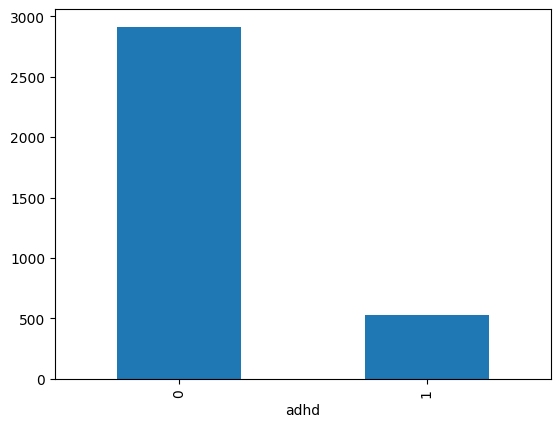

In [ ]:
target_count = clean_df["adhd"].value_counts().sort_index()

no_adhd = target_count.get(0, 0)
adhd = target_count.get(1, 0)

print(f"no_adhd: {no_adhd}")
print(f"adhd: {adhd}")

if adhd > 0:
    print(f"percentage (no_adhd : adhd) = {round(no_adhd / adhd, 2)} : 1")
else:
    print("percentage: undefined (no ADHD cases)")

target_count.plot(kind="bar")

We wanted to understand job role better and if it is affecting self reported signal

In [ ]:
messy_job_unique = clean_df['job_spec'].unique()
print(messy_job_unique)
print(f"the number of messy response for job_spec: {len(messy_job_unique)}")

<StringArray>
[                                                                                                              'back-end developer',
                                                                                           'back-end developer|front-end developer',
                                                                                                             'supervisor/team lead',
 'executive leadership|supervisor/team lead|dev evangelist/advocate|devops/sysadmin|support|back-end developer|front-end developer',
                                                          'devops/sysadmin|support|back-end developer|front-end developer|designer',
                                                                                       'dev evangelist/advocate|back-end developer',
                                                                                       'support|back-end developer|one-person shop',
                                                       

These inforamtion would need to be extracted differently

In [ ]:
# very messy, extract job roles
job_df = (
    clean_df[["job_spec"]]
    .dropna(subset=["job_spec"])
    .assign(
        job_role=lambda d: d["job_spec"].str.split("|")
    )
    .explode("job_role")
    .assign(
        job_role=lambda d: d["job_role"].str.strip().str.lower()
    )
)

job_df

,job_spec,job_role
0,back-end developer,back-end developer
1,back-end developer|front-end developer,back-end developer
1,back-end developer|front-end developer,front-end developer
2,back-end developer,back-end developer
3,supervisor/team lead,supervisor/team lead
...,...,...
1428,other,other
1429,support,support
1430,back-end developer,back-end developer
1431,devops/sysadmin,devops/sysadmin


In [ ]:
job_list = job_df['job_role'].unique()
print(job_list)
print("="*80)
print(f"After explode and splitting it the number of unique is reduced from {len(messy_job_unique)} to {len(job_list)}")


['back-end developer' 'front-end developer' 'supervisor/team lead'
 'executive leadership' 'dev evangelist/advocate' 'devops/sysadmin'
 'support' 'designer' 'one-person shop' 'other' 'sales' 'hr']
After explode and splitting it the number of unique is reduced from 265 to 12


1. This would require creating a multi-label binariser + one hot encoder together to avoid data leakage

In [ ]:
job_role_counts = (
    job_df["job_role"]
    .value_counts()
    .rename_axis("job_role")
    .reset_index(name="count")
)

job_role_counts["count"] = pd.to_numeric(job_role_counts["count"], errors="coerce")

job_role_counts["percent"] = (
    job_role_counts["count"] / job_role_counts["count"].sum() * 100
).round(2)

job_role_counts

,job_role,count,percent
0,back-end developer,737,27.38
1,front-end developer,502,18.65
2,devops/sysadmin,282,10.48
3,supervisor/team lead,277,10.29
4,other,187,6.95
5,support,168,6.24
6,one-person shop,161,5.98
7,designer,135,5.01
8,executive leadership,101,3.75
9,dev evangelist/advocate,99,3.68


## ADHD pre, during and post covid

Assume:  
Pre-COVID:    ≤ 2019  
During-COVID: 2020–2021  
Post-COVID:   ≥ 2022

In [ ]:
df_covid = clean_df.copy()
df_covid['year'] = df_covid['year'].astype(int)

df_covid["covid_period"] = pd.cut(
    df_covid["year"],
    bins=[2015, 2019, 2021, 2023],
    labels=["pre_covid(as of 2019)", "during_covid(2020-2021)", "post_covid(2022 onwards)"]
)

target_dist_covid_pct = (
    pd.crosstab(
        df_covid["covid_period"],
        df_covid["adhd"],
        normalize="index"  
    )
    * 100
).round(2)

target_dist_covid_pct


adhd,0,1
covid_period,,
pre_covid(as of 2019),84.31,15.69
during_covid(2020-2021),87.78,12.22
post_covid(2022 onwards),85.88,14.12


COVID data doesn't show deviation on ADHD signal, so it is okay to proceed forward with "COVID data" included for this study.|

## Trend year over year - ADHD proportion

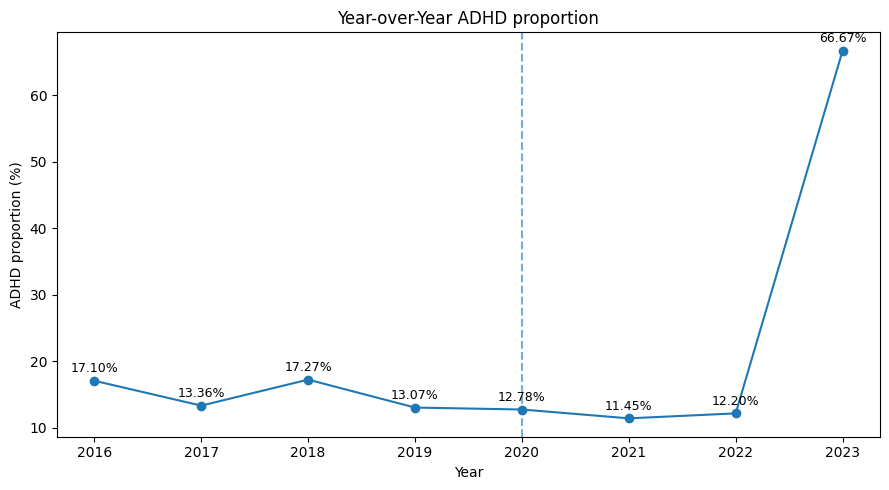

In [ ]:
adhd_yoy_pct = (
    pd.crosstab(
        df_covid["year"],
        df_covid["adhd"],
        normalize="index"
    )
    * 100
)[1]

plt.figure(figsize=(9, 5))
plt.plot(
    adhd_yoy_pct.index,
    adhd_yoy_pct.values,
    marker="o"
)
plt.axvline(2020, linestyle="--", alpha=0.6)
plt.xticks(adhd_yoy_pct.index, rotation=0)

for year, pct in adhd_yoy_pct.items():
    plt.annotate(
        f"{pct:.2f}%",
        (year, pct),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=9
    )

plt.xlabel("Year")
plt.ylabel("ADHD proportion (%)")
plt.title("Year-over-Year ADHD proportion")
plt.tight_layout()
plt.show()


2023 only has 6 responses, therefore year should be dropped as a feature for ML.

## Demographic & geographic discovery

Demographic Features:
- race
- self_employed
- company_size
- remote_work
- tech_current
- tech_previous
- tech_role
- job_spec

Geographic Features:
- country_live
- country_work
- us_state_live
- us_state_work

In [ ]:
def demo_summary(df, col):
    tab = (
        df[col]
        .astype("object")
        .fillna("Missing")
        .value_counts()
        .to_frame("count")
    )
    tab["percent"] = (tab["count"] / tab["count"].sum() * 100).round(2)
    return tab

demo_cols = [
    "race",
    "self_employed",
    "company_size",
    "remote_work",
    "tech_current",
    "tech_previous",
    "tech_role"
]

demo_tables = {col: demo_summary(clean_df, col) for col in demo_cols}

# example
demo_tables["race"]


,count,percent
race,,
Missing,2244,65.25
white,1010,29.37
asian,59,1.72
more than one of the above,40,1.16
i prefer not to answer,34,0.99
black or african american,19,0.55
hispanic,4,0.12
latino,4,0.12
latina,3,0.09


In [ ]:
#======== Race grouping ============
def recode_race(x):
    if pd.isna(x):
        return "Missing"
    x = x.lower()
    
    if "prefer not" in x:
        return "Prefer not to answer"
    
    if "white" in x or "caucasian" in x or "european" in x:
        return "White"
    
    if "asian" in x or "south asian" in x or "indian" in x or "persian" in x:
        return "Asian"
    
    if "black" in x or "african" in x:
        return "Black"
    
    if "hispanic" in x or "latino" in x or "latina" in x or "latinx" in x or "mestizo" in x:
        return "Hispanic / Latino"
    
    if "middle eastern" in x or "ashkenazi" in x or "jewish" in x:
        return "Middle Eastern"
    
    if "american indian" in x or "alaska native" in x:
        return "Indigenous"
    
    return "Mixed / Other"

clean_df['race_grouped'] = clean_df['race'].apply(recode_race)
clean_df = clean_df.drop(columns = 'race')

### Company size vs. ADHD

encoding table
1-5 = 0,
6-25 = 1,
26-100 = 2,
100-500	= 3,
500-1000 = 4,
more than 1000 = 5,
Missing


In [ ]:
def demo_vs_target(df, col, target="adhd"):
    # Make a copy or work on a view to avoid SettingWithCopyWarning
    s = df[col].copy()
    
    # Convert to object dtype so we can safely put "Missing"
    s = s.astype("object")
    
    # Fill NaN with string label
    s = s.fillna("Missing")
    
    tab = pd.crosstab(
        s,
        df[target],
        normalize="index"
    ) * 100
    
    return tab.round(2)

# Usage
demo_vs_target(clean_df, "company_size")

adhd,0,1
company_size,,
0,87.00,13.00
1,88.38,11.62
2,82.90,17.10
3,85.36,14.64
4,85.90,14.10
5,84.02,15.98
Missing,83.16,16.84


### Country

In [ ]:
geo_country_live = demo_summary(clean_df, "country_live")

top10_countries = geo_country_live.head(10)
top10_countries

,count,percent
country_live,,
united states of america,2036,59.20
united kingdom,321,9.33
canada,153,4.45
germany,110,3.20
india,101,2.94
netherlands,83,2.41
australia,62,1.80
brazil,47,1.37
france,43,1.25


Reviewing states results

In [ ]:
# US Only
us_only = (clean_df["country_live"] == "united states of america")

us_state_summary = demo_summary(
    clean_df.loc[us_only],
    "us_state_live"
)

us_state_summary.head(10)


,count,percent
us_state_live,,
california,267,13.11
illinois,202,9.92
washington,111,5.45
new york,104,5.11
michigan,89,4.37
minnesota,84,4.13
texas,83,4.08
ohio,82,4.03
tennessee,80,3.93


In [ ]:
# proportion (%)
geo_adhd_pct = (
    pd.crosstab(
        clean_df["country_live"],
        clean_df["adhd"],
        normalize="index"
    ) * 100
).round(2)

# sample size per group
geo_n = clean_df["country_live"].value_counts().rename("count")

# combine
geo_adhd_summary = geo_adhd_pct.merge(
    geo_n,
    left_index=True,
    right_index=True
)

geo_adhd_summary

,0,1,count
country_live,,,
afghanistan,33.33,66.67,3
albania,100.00,0.00,1
algeria,50.00,50.00,2
argentina,100.00,0.00,6
aruba,100.00,0.00,1
...,...,...,...
united kingdom,91.90,8.10,321
united states of america,79.81,20.19,2036
uruguay,50.00,50.00,2


We can observe the number of participant from certain country are too low, advise to group based on continent to improve data count

In [ ]:
#=== Convert Country to Continent ===
def get_continent(country):
    if pd.isna(country) or str(country).strip() == '':
       return 'Unknown'
    try:
       return cc.convert(names=country, to='continent',not_found='Unknown')
    except:
       return 'Unknown'

cc = coco.CountryConverter()

clean_df['continent_live'] = clean_df['country_live'].apply(get_continent)
clean_df['continent_work'] = clean_df['country_work'].apply(get_continent)

clean_df = clean_df.drop(columns = ['country_live','country_work'])

other not found in regex
other not found in regex
other not found in regex
other not found in regex
other not found in regex


In [ ]:
clean_df['us_state_live'].dropna().unique()

<StringArray>
[            'illinois',            'tennessee',             'virginia',
           'california',             'kentucky',               'oregon',
         'pennsylvania',           'new jersey',              'georgia',
           'washington',             'new york',              'indiana',
            'minnesota',        'west virginia',              'florida',
        'massachusetts',         'north dakota',                'texas',
             'maryland',            'wisconsin',             'michigan',
              'vermont',       'north carolina',               'kansas',
 'district of columbia',               'nevada',                 'utah',
          'connecticut',             'colorado',                 'ohio',
                 'iowa',         'south dakota',             'nebraska',
                'maine',             'missouri',              'arizona',
             'oklahoma',                'idaho',         'rhode island',
              'alabama',            '

In [ ]:
clean_df['us_state_work'].dropna().unique()

<StringArray>
[            'illinois',            'tennessee',             'virginia',
           'california',             'kentucky',               'oregon',
         'pennsylvania',           'new jersey',              'georgia',
           'washington',             'new york',              'indiana',
            'minnesota',                 'ohio',              'florida',
        'massachusetts',         'north dakota',                'texas',
 'district of columbia',             'michigan',              'vermont',
       'north carolina',             'missouri',               'kansas',
               'nevada',                 'utah',          'connecticut',
             'maryland',             'colorado',                 'iowa',
         'south dakota',               'hawaii',             'nebraska',
                'maine',              'arizona',             'oklahoma',
            'wisconsin',         'rhode island',              'alabama',
        'west virginia',            '

In [ ]:
#=== maps state to region ===
def normalize_state(state):
    if pd.isna(state):
        return np.nan

    state = str(state).strip().upper()  # 'il' → 'IL', 'illinois' → 'ILLINOIS'
    
    # Case 1: Already 2-letter code
    if len(state) == 2 and state.isalpha():
        return state  # e.g. 'IL'
    
    # Case 2: Full name → convert to abbr if match
    state_lower = state.lower()
    if state_lower in us_state_full_to_abbrev:
        return us_state_full_to_abbrev[state_lower]
    
    # Case 3: No match → try partial match or leave as-is / mark unknown
    return 'UNKNOWN'


# US State Abbreviation (uppercase) → Full Name (title case)
us_state_abbrev_to_full = {
    'AL': 'Alabama',
    'AK': 'Alaska',
    'AZ': 'Arizona',
    'AR': 'Arkansas',
    'CA': 'California',
    'CO': 'Colorado',
    'CT': 'Connecticut',
    'DE': 'Delaware',
    'FL': 'Florida',
    'GA': 'Georgia',
    'HI': 'Hawaii',
    'ID': 'Idaho',
    'IL': 'Illinois',
    'IN': 'Indiana',
    'IA': 'Iowa',
    'KS': 'Kansas',
    'KY': 'Kentucky',
    'LA': 'Louisiana',
    'ME': 'Maine',
    'MD': 'Maryland',
    'MA': 'Massachusetts',
    'MI': 'Michigan',
    'MN': 'Minnesota',
    'MS': 'Mississippi',
    'MO': 'Missouri',
    'MT': 'Montana',
    'NE': 'Nebraska',
    'NV': 'Nevada',
    'NH': 'New Hampshire',
    'NJ': 'New Jersey',
    'NM': 'New Mexico',
    'NY': 'New York',
    'NC': 'North Carolina',
    'ND': 'North Dakota',
    'OH': 'Ohio',
    'OK': 'Oklahoma',
    'OR': 'Oregon',
    'PA': 'Pennsylvania',
    'RI': 'Rhode Island',
    'SC': 'South Carolina',
    'SD': 'South Dakota',
    'TN': 'Tennessee',
    'TX': 'Texas',
    'UT': 'Utah',
    'VT': 'Vermont',
    'VA': 'Virginia',
    'WA': 'Washington',
    'WV': 'West Virginia',
    'WI': 'Wisconsin',
    'WY': 'Wyoming',
    'DC': 'District of Columbia',
    'AS': 'American Samoa'
}

# Reverse mapping: Full Name (lowercase) → Abbreviation (uppercase)
us_state_full_to_abbrev = {v.lower(): k for k, v in us_state_abbrev_to_full.items()}

# Apply to your columns
clean_df['state_live_norm'] = clean_df['us_state_live'].apply(normalize_state)
clean_df['state_work_norm'] = clean_df['us_state_work'].apply(normalize_state)

us_region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast',
    
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'SD': 'Midwest',
    
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South',
    'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'NM': 'West', 'MT': 'West',
    'UT': 'West', 'NV': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West',
    
    'AS': 'Territory',  # or 'Other'
}

# Map normalized codes to regions
clean_df['region_live'] = clean_df['state_live_norm'].map(us_region_map).fillna('Unknown')
clean_df['region_work'] = clean_df['state_work_norm'].map(us_region_map).fillna('Unknown')

clean_df = clean_df.drop(columns = ['state_live_norm','state_work_norm','us_state_live','us_state_work'])

Each column should have normal value as it should be binarise or Nan

In [ ]:
clean_df.describe()

,other,describe_the_circumstances_of_the_supportive_or_well_handled_response.,have_you_been_diagnosed_with_covid_19,Age,self_employed,company_size,tech_current,tech_previous,tech_role,remote_work,...,willing_interview_followup,prev_coworker_discussed_mh_with_you,discuss_employer_neg_conseq,current_mh,past_mh,diagnosed_mh,family_history_mh,signal_from_clinical,other_disorder,signal_from_self
count,0.0,0.0,0.0,3437.000000,0.0,2851.0,2851.0,1682.0,1968.0,0.0,...,2004.0,1669.0,1146.0,3254.0,3263.0,2240.0,2703.0,3439.000000,3439.000000,3439.000000
mean,NaN,NaN,NaN,34.838813,<NA>,2.997545,0.741845,0.671819,0.930386,<NA>,...,0.348802,0.336129,0.810646,1.07099,1.148943,0.66875,1.135035,0.453329,0.011341,0.114568
std,NaN,NaN,NaN,10.541767,<NA>,1.52534,0.437696,0.469691,0.25456,<NA>,...,0.47671,0.472525,0.734615,0.879559,0.890996,0.470768,0.991024,0.497889,0.105902,0.318546
min,NaN,NaN,NaN,0.000000,<NA>,0.0,0.0,0.0,0.0,<NA>,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,28.000000,<NA>,2.0,0.0,0.0,1.0,<NA>,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,34.000000,<NA>,3.0,1.0,1.0,1.0,<NA>,...,0.0,0.0,1.0,1.0,1.0,1.0,2.0,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,40.000000,<NA>,5.0,1.0,1.0,1.0,<NA>,...,1.0,1.0,1.0,2.0,2.0,1.0,2.0,1.000000,0.000000,0.000000
max,NaN,NaN,NaN,323.000000,<NA>,5.0,1.0,1.0,1.0,<NA>,...,1.0,1.0,2.0,2.0,2.0,1.0,2.0,1.000000,1.000000,1.000000


describe on Age revealed some outliers <br>
Min = 0, Max = 323

Dropping Free text col, after reviewing it the understanding is that it might not contain information for 

In [ ]:
clean_df = clean_df.drop(columns=FREE_TEXT_COL, errors='ignore')
clean_df = clean_df.dropna(axis=1, how='all')

In [ ]:
def encode_mnar_columns(df: pd.DataFrame, year_col: str = 'year', threshold: float = 0.9):
    df = df.copy()
    if year_col not in df.columns:
        print(f"Warning: '{year_col}' not found — skipping MNAR encoding.")
        return df, []

    mnar_cols = []
    for col in df.columns:
        if col in (year_col, 'job_spec'):
            continue
        if not df[col].isna().any():
            continue
        year_miss = df.groupby(year_col)[col].apply(lambda s: s.isna().mean())
        if year_miss.max() >= threshold:
            mnar_cols.append(col)
            # Use type-appropriate fill value to avoid mixed-type columns
            if df[col].dtype == object or str(df[col].dtype) == 'string':
                df[col] = df[col].fillna("Not_Asked")
            else:
                df[col] = df[col].fillna(-1)

    print(f"\nMNAR columns encoded ({len(mnar_cols)} total):")
    for c in mnar_cols:
        print(f"  {c}")
    return df, mnar_cols

clean_df, mnar_cols = encode_mnar_columns(clean_df)


MNAR columns encoded (16 total):
  tech_previous
  mh_treatment_history
  discussed_with_coworkers
  discussed_with_employer
  mental_vs_physical_comfort_prev_employer
  mental_vs_physical_comfort_coworker
  industry_support_mh
  discuss_mh_with_prev_employer
  disclose_mh_clients_business_current
  disclose_mh_coworkers_current
  observed_coworker_discuss_mh
  past_disclose_mh_coworker
  openly_identified_mh_at_work
  willing_interview_followup
  prev_coworker_discussed_mh_with_you
  discuss_employer_neg_conseq


In [ ]:
# Check MNAR columns — ADHD rate by value group after dropping 2014
for col in mnar_cols:
    if col not in clean_df.columns:
        continue
    result = clean_df.groupby(col)['adhd'].mean()
    print(f"\n{col}")
    print(result)


tech_previous
tech_previous
-1    0.159932
0     0.155797
1     0.140708
Name: adhd, dtype: float64

mh_treatment_history
mh_treatment_history
-1    0.170970
0     0.043995
1     0.209442
Name: adhd, dtype: float64

discussed_with_coworkers
discussed_with_coworkers
-1    0.164179
0     0.092999
1     0.204054
Name: adhd, dtype: float64

discussed_with_employer
discussed_with_employer
-1    0.164937
0     0.112245
1     0.204159
Name: adhd, dtype: float64

mental_vs_physical_comfort_prev_employer
mental_vs_physical_comfort_prev_employer
-1    0.159932
0     0.143433
1     0.156250
2     0.080000
Name: adhd, dtype: float64

mental_vs_physical_comfort_coworker
mental_vs_physical_comfort_coworker
-1    0.164937
0     0.135889
1     0.145038
2     0.242424
Name: adhd, dtype: float64

industry_support_mh
industry_support_mh
-1    0.171429
1     0.124555
2     0.150327
3     0.119347
4     0.194139
5     0.119048
Name: adhd, dtype: float64

discuss_mh_with_prev_employer
discuss_mh_with_prev_

In [ ]:
EXCLUDE = [
    'job_spec',
    'diagnosed_mh',
    'current_mh',
    'past_mh',
    'signal_from_clinical'
    ]

def add_missing_indicators(df: pd.DataFrame, exclude: list = None, threshold: float = 0.05):
    df = df.copy()
    exclude = exclude or []
    added = []
    for col in df.columns:
        if col in exclude:
            continue
        if df[col].isna().mean() > threshold:
            df[f"{col}_missing"] = df[col].isna().astype(int)
            added.append(f"{col}_missing")
    print(f"\nMissingness indicator columns added: {len(added)}")
    for c in added:
        print(f"  {c}")
    return df

clean_df = add_missing_indicators(clean_df, exclude=EXCLUDE)

print(f"\nShape after MNAR + indicator flags: {clean_df.shape}")


Missingness indicator columns added: 11
  company_size_missing
  tech_current_missing
  tech_role_missing
  work_mh_benefits_current_missing
  open_to_discuss_coworkers_missing
  open_to_discuss_supervisor_current_missing
  open_to_discuss_supervisor_prev_missing
  willing_share_family_missing
  discuss_mh_with_prev_coworkers_missing
  vicarious_stigma_effect_missing
  family_history_mh_missing

Shape after MNAR + indicator flags: (3439, 66)


In [ ]:
output = "C:\\Users\\User\\OneDrive\\DS_master\\SIADS_696_Milestone II\\Team project\\Data\\PartA_df.csv"
clean_df.to_csv(output)

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3439 entries, 0 to 3438
Data columns (total 66 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   year                                        3439 non-null   object 
 1   Age                                         3437 non-null   float64
 2   company_size                                2851 non-null   Int64  
 3   tech_current                                2851 non-null   Int64  
 4   tech_previous                               3439 non-null   Int64  
 5   tech_role                                   1968 non-null   Int64  
 6   job_spec                                    1433 non-null   string 
 7   adhd                                        3439 non-null   int64  
 8   anxiety                                     3439 non-null   int64  
 9   mood                                        3439 non-null   int64  
 10  eating      